# 🏥 Healthcare Datathon — Sleep Health Starter Notebook

**Welcome to the Healthcare Track!**

This notebook is your launchpad. It walks you through loading and exploring a real-world sleep health dataset, cleaning it up, and building a baseline predictive model. Think of it as the foundation — your team's job is to dig deeper, ask better questions, and build something more interesting.

---

## About the Dataset

The **Sleep Health and Lifestyle Dataset** contains health and lifestyle records for 374 individuals. Each row represents one person, with features covering:

| Feature | Description |
|---|---|
| `Age`, `Gender`, `Occupation` | Demographic info |
| `Sleep Duration` | Hours of sleep per night |
| `Quality of Sleep` | Self-reported score (1–10) |
| `Physical Activity Level` | Minutes of daily activity |
| `Stress Level` | Self-reported score (1–10) |
| `BMI Category` | Underweight / Normal / Overweight / Obese |
| `Blood Pressure` | Systolic/diastolic (e.g. 126/83) |
| `Heart Rate` | Resting BPM |
| `Daily Steps` | Step count |
| `Sleep Disorder` | None / Sleep Apnea / Insomnia |

---

## How to Use This Notebook

1. **Run every cell top to bottom** to reproduce the baseline.
2. **Read the questions** at the end of each section — they're prompts to help guide your team's exploration.
3. **Fork off from here.** Add new cells, try new models, engineer new features, or pivot to a different target variable entirely.

> **Your goal isn't to copy this notebook — it's to use it as a jumping-off point.**

---
## Section 0 — Setup

Import libraries and configure display settings.

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Display settings
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

print('Libraries loaded successfully.')

Libraries loaded successfully.


---
## Section 1 — Load & First Look

Always start by understanding what you're working with before touching anything.

In [15]:
df = pd.read_csv('sleep_dataset.csv')
print(f'Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns')
df.head(10)

Dataset shape: 374 rows × 13 columns


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
5,6,Male,28,Software Engineer,5.9,4,30,8,Obese,140/90,85,3000,Insomnia
6,7,Male,29,Teacher,6.3,6,40,7,Obese,140/90,82,3500,Insomnia
7,8,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN
8,9,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN
9,10,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN


In [16]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [17]:
# Summary statistics for numeric columns
df.describe().round(2)

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.00,374.00,374.00,374.00,374.00,374.00,374.00,374.00
mean,187.50,42.18,7.13,7.31,59.17,5.39,70.17,6816.84
std,108.11,8.67,0.80,1.20,20.83,1.77,4.14,1617.92
min,1.00,27.00,5.80,4.00,30.00,3.00,65.00,3000.00
25%,94.25,35.25,6.40,6.00,45.00,4.00,68.00,5600.00
50%,187.50,43.00,7.20,7.00,60.00,5.00,70.00,7000.00
75%,280.75,50.00,7.80,8.00,75.00,7.00,72.00,8000.00
max,374.00,59.00,8.50,9.00,90.00,8.00,86.00,10000.00


### 🤔 Questions to Explore

- What is the range of `Quality of Sleep`? Is it normally distributed?
- Are there any numeric columns with unexpectedly large or small ranges?
- What does the `Sleep Disorder` column represent? How many unique values does it have?

> **Try:** `df['Sleep Disorder'].value_counts()`

---
## Section 2 — Missing Values & Data Cleaning

Real datasets are messy. Understanding missingness is a crucial first step before modeling.

In [18]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)

missing_summary = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).query('`Missing Count` > 0')

print('Columns with missing values:')
print(missing_summary if not missing_summary.empty else 'None found.')

Columns with missing values:
                Missing Count  Missing %
Sleep Disorder            219       58.6


In [19]:
# The Sleep Disorder column uses NaN to mean 'None' — let's fix that
df['Sleep Disorder'] = df['Sleep Disorder'].fillna('None')

print('Sleep Disorder value counts after cleaning:')
print(df['Sleep Disorder'].value_counts())

Sleep Disorder value counts after cleaning:
Sleep Disorder
None           219
Sleep Apnea     78
Insomnia        77
Name: count, dtype: int64


In [20]:
# Blood Pressure is a string like '126/83' — let's split it into two numeric features
bp_split = df['Blood Pressure'].str.split('/', expand=True).astype(int)
df['BP_Systolic'] = bp_split[0]
df['BP_Diastolic'] = bp_split[1]

# Drop the original string column
df = df.drop(columns=['Blood Pressure'])

print('Blood Pressure columns added:')
df[['BP_Systolic', 'BP_Diastolic']].describe().round(2)

Blood Pressure columns added:


,BP_Systolic,BP_Diastolic
count,374.00,374.00
mean,128.55,84.65
std,7.75,6.16
min,115.00,75.00
25%,125.00,80.00
50%,130.00,85.00
75%,135.00,90.00
max,142.00,95.00


### 🤔 Questions to Explore

- What does it mean clinically when `Sleep Disorder` is `None`? Is that the same as no disorder being *detected*?
- Are there any duplicate rows (`df.duplicated().sum()`)?
- `Person ID` is just an index — does it belong in a model? What should you do with it?
- The `Blood Pressure` parsing above is one approach. What are the tradeoffs of treating it as a ratio instead? As a categorical (e.g., hypertensive vs. normal)?

---
## Section 3 — Exploratory Data Analysis (EDA)

Before modeling, understand your data visually. Look for patterns, distributions, and relationships.

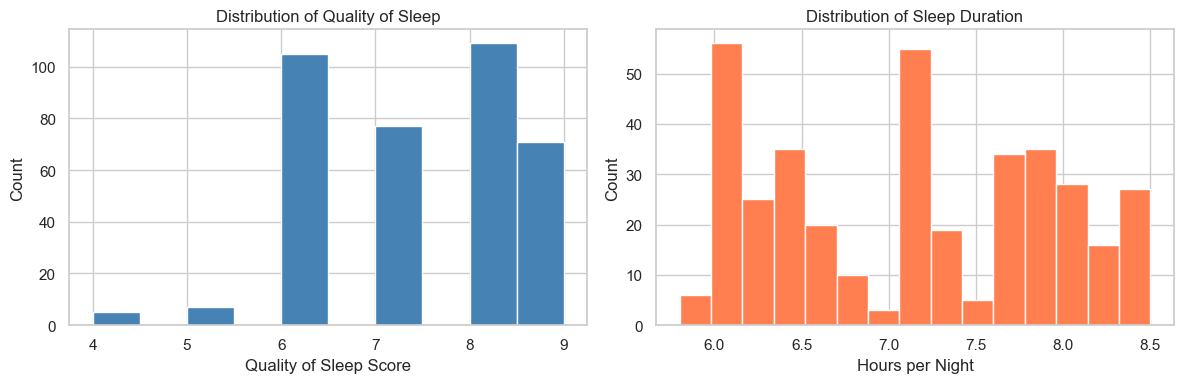

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution of target variable
axes[0].hist(df['Quality of Sleep'], bins=10, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Quality of Sleep')
axes[0].set_xlabel('Quality of Sleep Score')
axes[0].set_ylabel('Count')

# Sleep Duration distribution
axes[1].hist(df['Sleep Duration'], bins=15, color='coral', edgecolor='white')
axes[1].set_title('Distribution of Sleep Duration')
axes[1].set_xlabel('Hours per Night')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

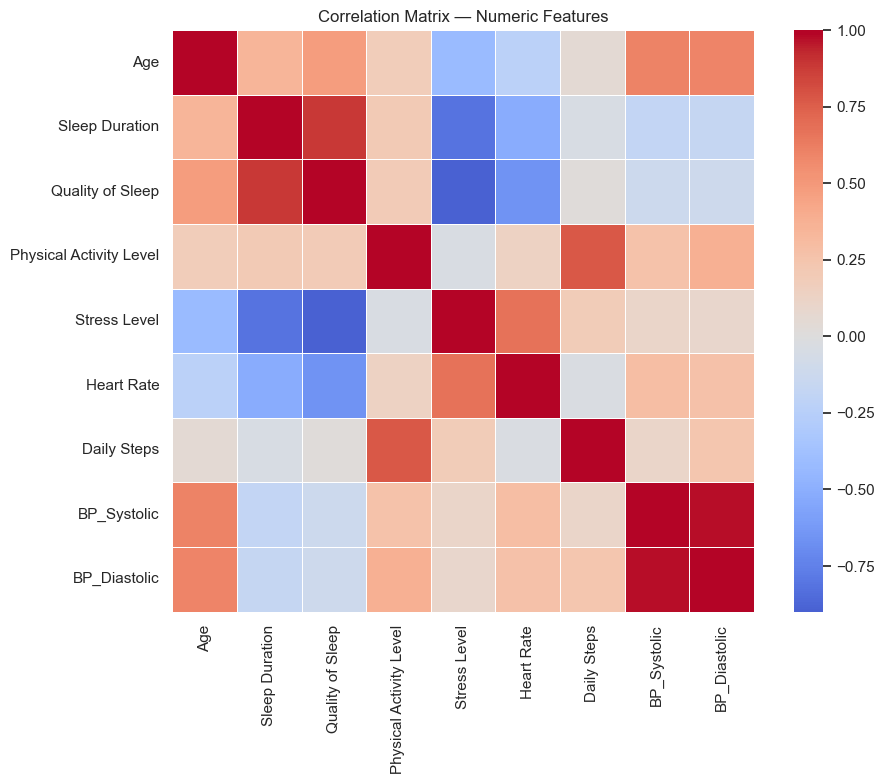

In [35]:
# Correlation heatmap for numeric features
numeric_cols = df.select_dtypes(include='number').drop(columns=['Person ID'])
corr_matrix = numeric_cols.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm', center=0,
    square=True, linewidths=0.5
)
plt.title('Correlation Matrix — Numeric Features')
plt.tight_layout()
plt.show()

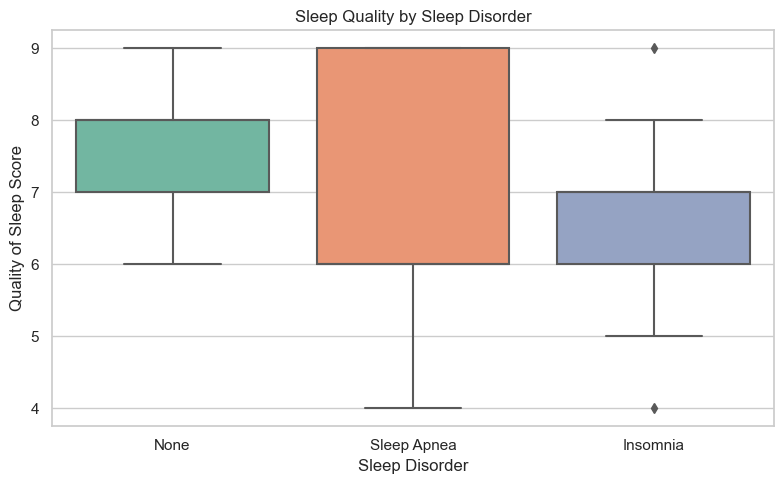

In [23]:
# Sleep quality by disorder type
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x='Sleep Disorder',
    y='Quality of Sleep',
    order=['None', 'Sleep Apnea', 'Insomnia'],
    palette='Set2'
)
plt.title('Sleep Quality by Sleep Disorder')
plt.xlabel('Sleep Disorder')
plt.ylabel('Quality of Sleep Score')
plt.tight_layout()
plt.show()

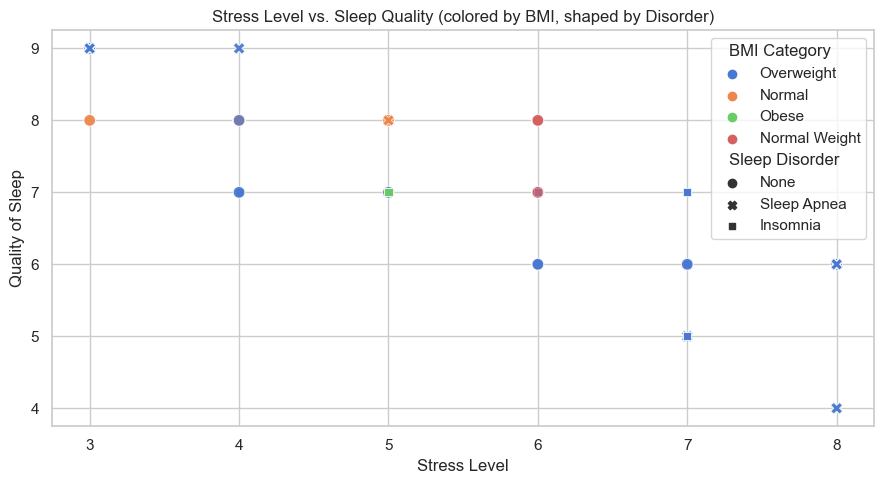

In [24]:
# Stress level vs. sleep quality — colored by BMI
plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=df,
    x='Stress Level',
    y='Quality of Sleep',
    hue='BMI Category',
    style='Sleep Disorder',
    alpha=0.75, s=70
)
plt.title('Stress Level vs. Sleep Quality (colored by BMI, shaped by Disorder)')
plt.tight_layout()
plt.show()

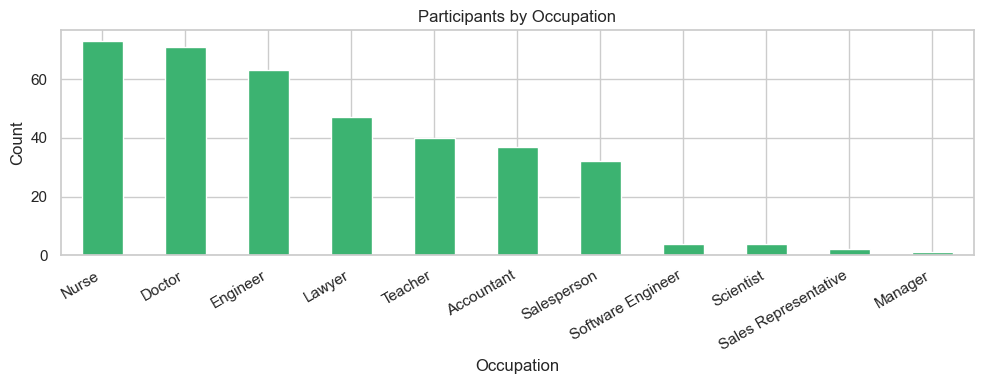

In [25]:
# Who is in this dataset?
occupation_counts = df['Occupation'].value_counts()

plt.figure(figsize=(10, 4))
occupation_counts.plot(kind='bar', color='mediumseagreen', edgecolor='white')
plt.title('Participants by Occupation')
plt.xlabel('Occupation')
plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

### 🤔 Questions to Explore

- From the correlation heatmap: which features are most strongly correlated with `Quality of Sleep`? Does that match your intuition?
- The `Stress Level` vs. `Quality of Sleep` plot shows a clear pattern — can you describe it? Is it linear?
- Does sleep quality differ by `Gender`? By `Occupation`? Try making your own plots.
- Are there any correlations that seem *suspicious* (almost too high)? What could explain them?
- Which occupations have the best and worst sleep quality? Is that meaningful or is it a data artifact?

> **Try:** `df.groupby('Occupation')['Quality of Sleep'].mean().sort_values()`

---
## Section 4 — Feature Engineering & Preprocessing

Before feeding data into a model, we need to encode categorical variables and decide which features to include.

In [26]:
# Drop Person ID (not a feature)
model_df = df.drop(columns=['Person ID'])

# One-hot encode categorical columns
model_df = pd.get_dummies(model_df, columns=['Gender', 'Occupation', 'BMI Category', 'Sleep Disorder'], drop_first=True)

print(f'Feature matrix shape: {model_df.shape}')
model_df.head(3)

Feature matrix shape: (374, 25)


,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,BP_Systolic,BP_Diastolic,Gender_Male,Occupation_Doctor,Occupation_Engineer,Occupation_Lawyer,Occupation_Manager,Occupation_Nurse,Occupation_Sales Representative,Occupation_Salesperson,Occupation_Scientist,Occupation_Software Engineer,Occupation_Teacher,BMI Category_Normal Weight,BMI Category_Obese,BMI Category_Overweight,Sleep Disorder_None,Sleep Disorder_Sleep Apnea
0,27,6.1,6,42,6,77,4200,126,83,True,False,False,False,False,False,False,False,False,True,False,False,False,True,True,False
1,28,6.2,6,60,8,75,10000,125,80,True,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False
2,28,6.2,6,60,8,75,10000,125,80,True,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False


In [27]:
# Target: Quality of Sleep
X = model_df.drop(columns=['Quality of Sleep'])
y = model_df['Quality of Sleep']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set:     {X_test.shape[0]} samples')

Training set: 299 samples
Test set:     75 samples


### 🤔 Questions to Explore

- We're predicting `Quality of Sleep` (a number). Could you reframe this as a **classification** problem instead? How?
- One-hot encoding creates many columns. Are there smarter ways to encode `Occupation`? (Think: frequency encoding, target encoding.)
- Should `Sleep Duration` be in the model if we're predicting sleep quality — or does that feel like cheating given how correlated they are?
- What other features could you *engineer* from the existing columns? (Example: pulse pressure = systolic - diastolic.)

---
## Section 5 — Baseline Models

We'll train three models of increasing complexity and compare their performance.

In [28]:
# --- Linear Regression ---
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

lr_r2  = r2_score(y_test, lr_pred)
lr_mse = mean_squared_error(y_test, lr_pred)
print(f'Linear Regression  |  R² = {lr_r2:.3f}  |  MSE = {lr_mse:.4f}')

Linear Regression  |  R² = 0.966  |  MSE = 0.0511


In [29]:
# --- Decision Tree ---
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

dt_r2  = r2_score(y_test, dt_pred)
dt_mse = mean_squared_error(y_test, dt_pred)
print(f'Decision Tree      |  R² = {dt_r2:.3f}  |  MSE = {dt_mse:.4f}')

Decision Tree      |  R² = 1.000  |  MSE = 0.0000


In [30]:
# --- Random Forest ---
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

rf_r2  = r2_score(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
print(f'Random Forest      |  R² = {rf_r2:.3f}  |  MSE = {rf_mse:.4f}')

Random Forest      |  R² = 0.982  |  MSE = 0.0268


In [31]:
# Summary table
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'R²': [lr_r2, dt_r2, rf_r2],
    'MSE': [lr_mse, dt_mse, rf_mse]
}).set_index('Model').round(4)

results

,R²,MSE
Model,,
Linear Regression,0.9661,0.0511
Decision Tree,1.0000,0.0000
Random Forest,0.9823,0.0268


---
## Section 6 — Model Evaluation & Visualization

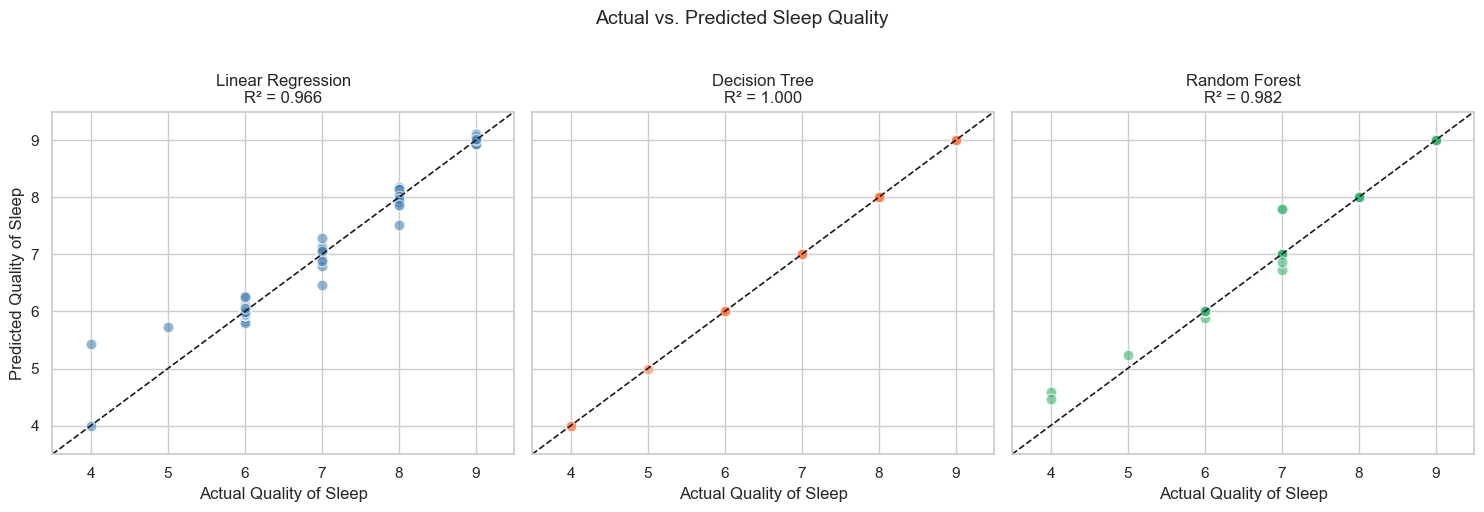

In [32]:
# Actual vs Predicted — all three models side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

model_data = [
    ('Linear Regression', lr_pred, 'steelblue'),
    ('Decision Tree',     dt_pred, 'coral'),
    ('Random Forest',     rf_pred, 'mediumseagreen'),
]

for ax, (name, preds, color) in zip(axes, model_data):
    ax.scatter(y_test, preds, alpha=0.6, color=color, edgecolors='white', s=60)
    lims = [y_test.min() - 0.5, y_test.max() + 0.5]
    ax.plot(lims, lims, 'k--', linewidth=1.2, label='Perfect prediction')
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_title(f'{name}\nR² = {r2_score(y_test, preds):.3f}')
    ax.set_xlabel('Actual Quality of Sleep')

axes[0].set_ylabel('Predicted Quality of Sleep')
plt.suptitle('Actual vs. Predicted Sleep Quality', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

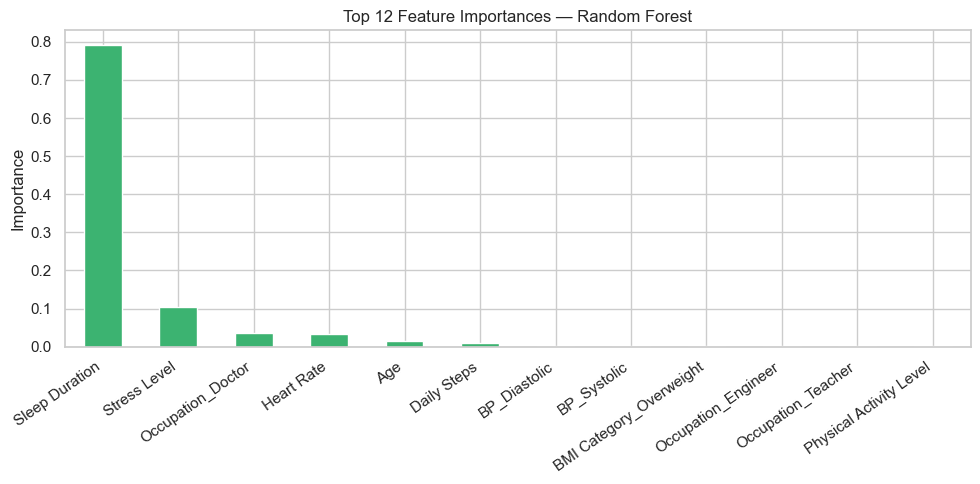

In [33]:
# Feature importance from the Random Forest
importances = pd.Series(rf.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(12)

plt.figure(figsize=(10, 5))
top_features.plot(kind='bar', color='mediumseagreen', edgecolor='white')
plt.title('Top 12 Feature Importances — Random Forest')
plt.ylabel('Importance')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

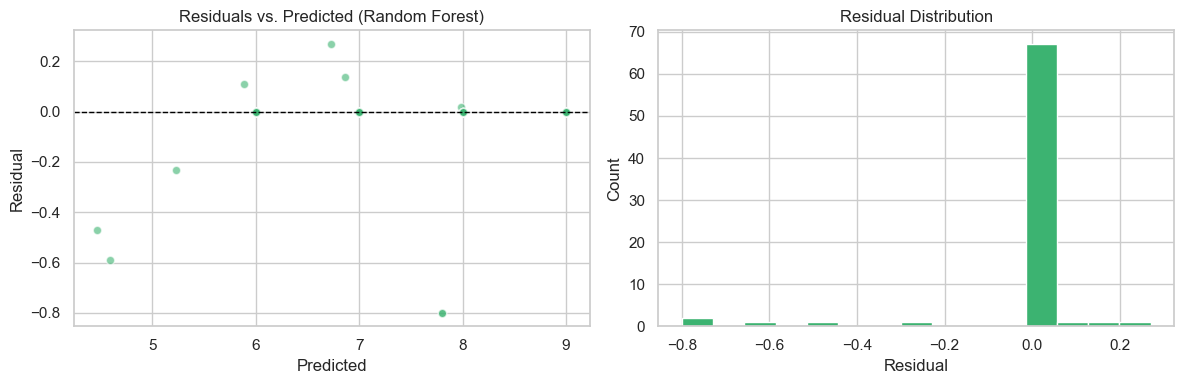

In [34]:
# Residuals plot for the Random Forest
residuals = y_test - rf_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Residuals vs Predicted
axes[0].scatter(rf_pred, residuals, alpha=0.6, color='mediumseagreen', edgecolors='white')
axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Residuals vs. Predicted (Random Forest)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Residual')

# Residual distribution
axes[1].hist(residuals, bins=15, color='mediumseagreen', edgecolor='white')
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

### 🤔 Questions to Explore

- The Random Forest achieves a very high R². Is that suspicious? What could cause overfitting on a small dataset?
- Look at the feature importance chart — which features matter most? Does that match what the correlation heatmap showed?
- Are residuals randomly scattered, or do you see patterns? What would a non-random residual pattern imply?
- The Decision Tree likely performs worse than the Random Forest. Why? What does Random Forest do differently?
- What happens to model performance if you remove `Sleep Duration` as a feature?

---
## Section 7 — How to Use This Model in Practice

### What Your Model Does

The Random Forest model learns patterns from individual health and lifestyle data to **predict a person's sleep quality score** based on:

- **Stress level** — one of the strongest predictors
- **Sleep duration** — more sleep generally means higher quality
- **Physical activity** — exercise correlates with better sleep
- **BMI category** — weight status impacts sleep health
- **Blood pressure** — a marker of cardiovascular health
- **Occupation & demographics** — lifestyle context
- **Sleep disorder status** — apnea and insomnia directly impact quality

---

### How Your Team Should Use It

**Scenario 1 — Predict sleep quality for a new individual**

```python
# Collect a person's health data, ensure columns match X
new_person = pd.DataFrame([{ ... }])
predicted_quality = rf.predict(new_person)
```
- If predicted quality is much lower than expected: *What risk factors stand out?*
- If predicted quality is higher than reported: *What is being underweighted by the model?*

**Scenario 2 — Identify key drivers of poor sleep**
- Use feature importance + EDA together to tell a story:
  - *"People with stress level ≥ 7 have X% lower sleep quality on average"*
  - *"Insomnia patients average Y fewer hours per night than those with no disorder"*

---

### Key Limitations — Always Mention These

| Limitation | Why It Matters |
|---|---|
| Small dataset (374 people) | Model may not generalize to broader populations |
| Self-reported features | Stress and sleep quality scores are subjective |
| Correlation ≠ Causation | High stress correlates with poor sleep — but which causes which? |
| No time dimension | Data is a snapshot; sleep patterns change over time |
| Sampling bias | Occupations in the dataset may not be representative |

---

### Your Presentation Story

| Slide | Content |
|---|---|
| **Question** | Can we predict an individual's sleep quality from lifestyle data? |
| **Data** | 374 individuals, 12 features covering lifestyle, health, and demographics |
| **EDA** | Stress level and sleep duration are the strongest correlates of sleep quality |
| **Model** | Random Forest outperforms linear models (R² = ?) — captures non-linear patterns |
| **Evidence** | Feature importance, actual vs. predicted plots, residual analysis |
| **Conclusion** | Stress and physical activity are key levers; *[your team's insight here]* |
| **Limits** | Acknowledge subjectivity, small N, and correlation/causation distinction |

---
## Section 8 — Where to Go From Here

This starter notebook covers the basics. Here are directions your team can explore:

### 🔬 Deepen the Analysis
- Segment by sleep disorder type — do models perform differently for Insomnia vs. Sleep Apnea patients?
- Explore interaction effects: does the impact of stress differ by occupation or BMI?
- Conduct a proper train/validation/test split or use cross-validation.

### 🤖 Try Different Models
- **Gradient Boosting** (`XGBoost`, `LightGBM`) — often beats Random Forest on tabular data
- **KNN Regressor** — how does nearest-neighbor perform?
- **Classification framing** — bucket sleep quality into Low / Medium / High and use a classifier

### 🏗️ Engineer Better Features
- `Pulse Pressure = BP_Systolic - BP_Diastolic` (cardiovascular health indicator)
- `Active Lifestyle` = binary flag for Physical Activity > threshold
- Age groups (young adult / middle age / senior)

### 📖 Frame a Stronger Narrative
- Who is most at risk for poor sleep? Build a risk profile.
- What interventions would you recommend based on the model?
- What additional data would make this model more useful in a clinical setting?

---

> **Good luck, and have fun!** The best datathon projects don't just build a model — they tell a story that a non-technical audience can act on.